<a href="https://colab.research.google.com/github/MNawfal24/PCVK_Ganjil_2026/blob/main/Week6_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
NAMA = 'Muhammad Nawfal Mawla Azhar'
NIM = '244107020174'
print(NAMA, NIM)

Muhammad Nawfal Mawla Azhar 244107020174


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [10]:
def convolution2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image_padded = np.pad(image, padding, mode='constant', constant_values=0)
    else:
        image_padded = image.copy()

    img_h, img_w = image_padded.shape
    k_h, k_w = kernel.shape

    out_h = math.floor((img_h - k_h) / stride) + 1
    out_w = math.floor((img_w - k_w) / stride) + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    for y in range(0, out_h):
        for x in range(0, out_w):
            region = image_padded[y*stride:y*stride+k_h, x*stride:x*stride+k_w]
            output[y, x] = np.sum(region * kernel)

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)


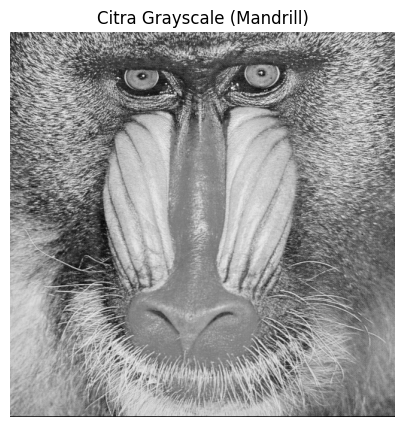

In [12]:
img = cv.imread('/content/drive/MyDrive/Pcvdk_Nawfal/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Grayscale (Mandrill)')
plt.axis('off')
plt.show()

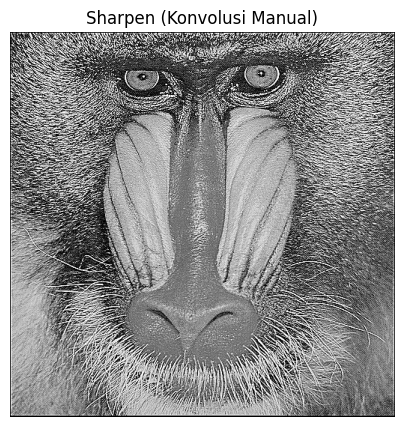

In [15]:
# Menentukan kernel sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# Memanggil fungsi konvolusi manual
result_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)

# Menampilkan hasil
plt.figure(figsize=(5, 5))
plt.imshow(result_sharpen, cmap='gray')
plt.title('Sharpen (Konvolusi Manual)')
plt.axis('off')
plt.show()

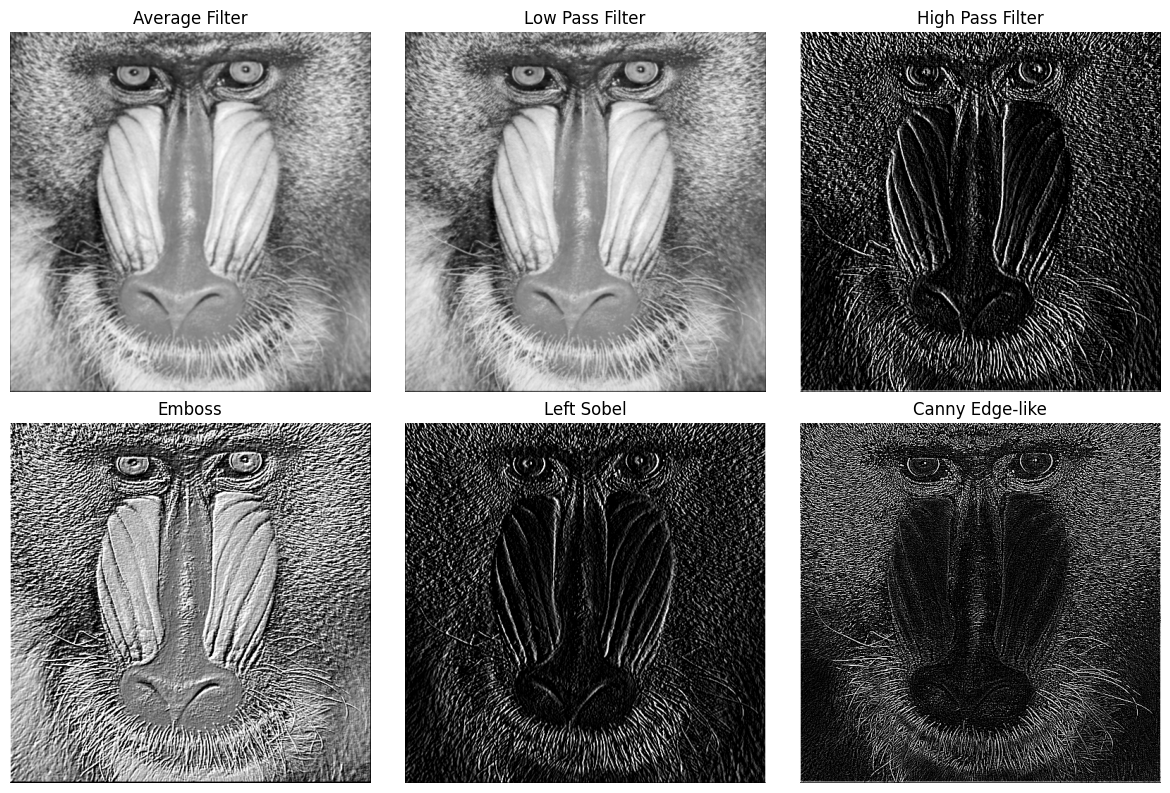

In [16]:
# 1. Average Filter 3x3
kernel_avg = (1/9) * np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])

# 2. Low Pass Filter
kernel_lpf = (1/12) * np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]])

# 3. High Pass Filter
kernel_hpf = np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]])

# 4. Emboss Filter
kernel_emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])

# 5. Left Sobel Edge Detection
kernel_sobel_left = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])

# 6. Canny-like / Laplacian-style Kernel
kernel_canny_like = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

filters = {
    "Average Filter": kernel_avg,
    "Low Pass Filter": kernel_lpf,
    "High Pass Filter": kernel_hpf,
    "Emboss": kernel_emboss,
    "Left Sobel": kernel_sobel_left,
    "Canny Edge-like": kernel_canny_like
}

plt.figure(figsize=(12, 8))
for i, (name, kern) in enumerate(filters.items()):
    res = convolution2d(img_gray, kern, stride=1, padding=1)
    plt.subplot(2, 3, i+1)
    plt.imshow(res, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()

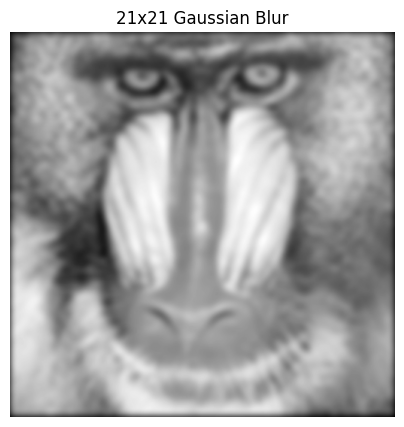

In [17]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel_2d = gaussian_kernel @ gaussian_kernel.transpose()

pad_size = kernel_size // 2
res_gauss = convolution2d(img_gray, gauss_kernel_2d, stride=1, padding=pad_size)

plt.figure(figsize=(5, 5))
plt.imshow(res_gauss, cmap='gray')
plt.title('21x21 Gaussian Blur')
plt.axis('off')
plt.show()

In [18]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

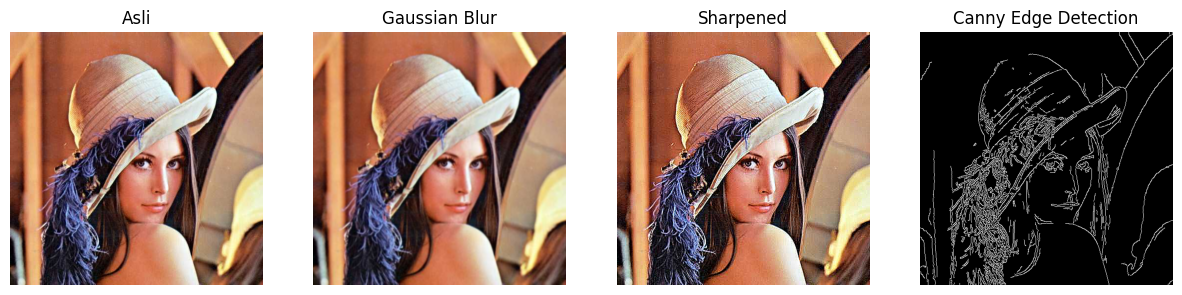

In [19]:
# Memuat citra 'lena.jpg' (pastikan path Google Drive sesuai)
img = cv.imread('/content/drive/MyDrive/Pcvdk_Nawfal/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

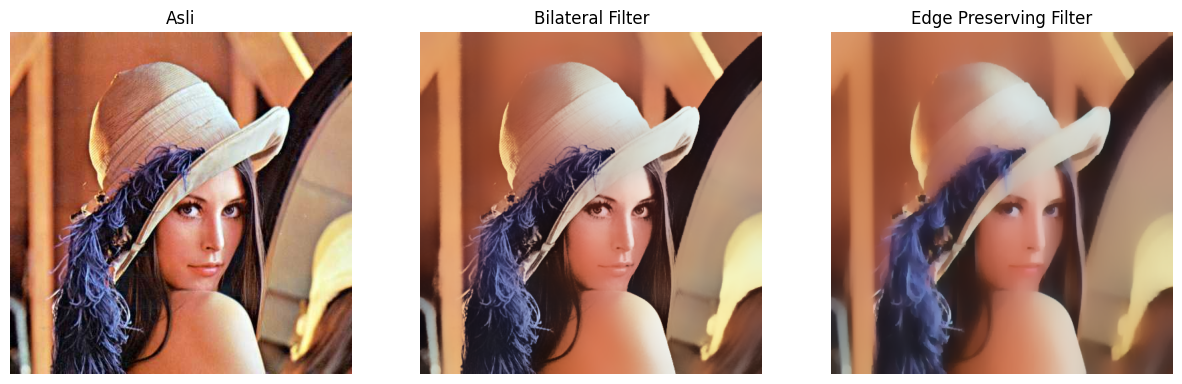

In [20]:
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

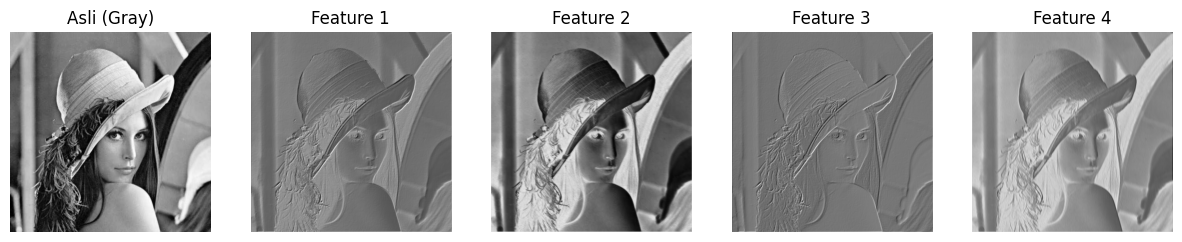

In [21]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

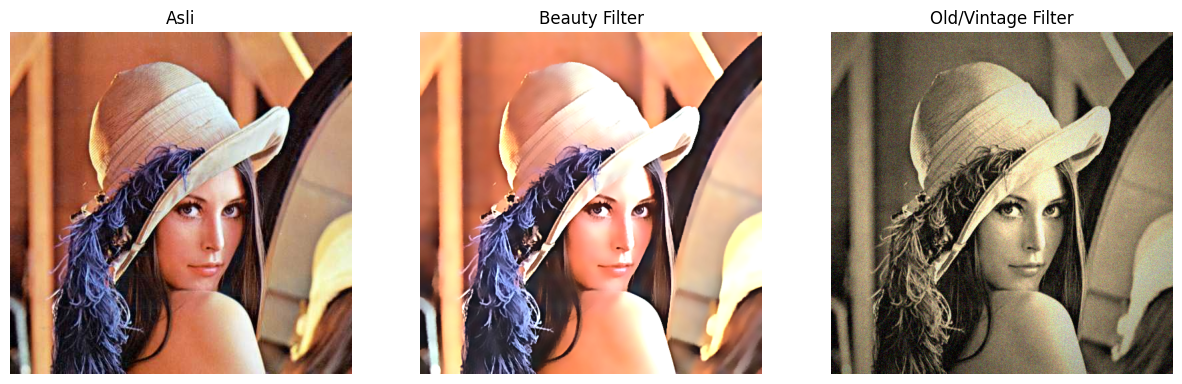

In [22]:
# 1. Beauty Filter

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# 2. Old/Vintage Filter

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Tampilkan Hasil Percobaan 4
show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

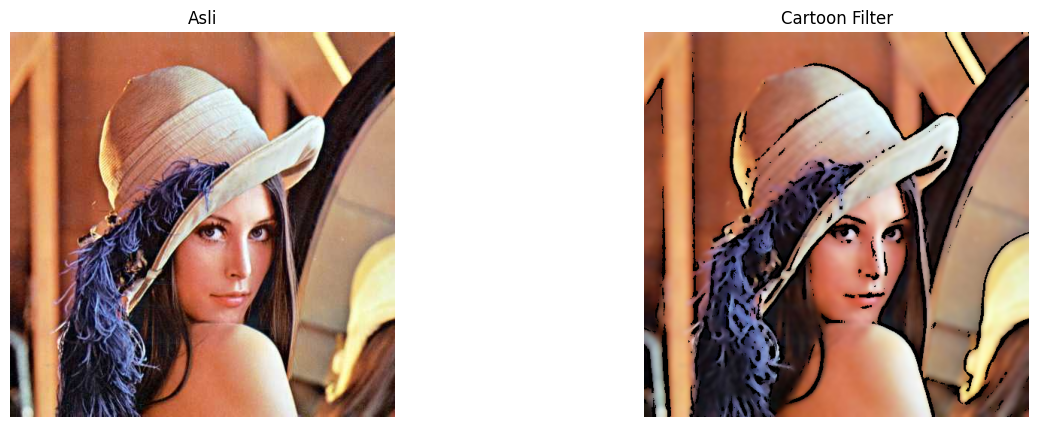

In [23]:
# Step 1: Edge detection (pakai median blur dulu agar gambar lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
edges_colored = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
cartoon = cv.bitwise_and(color, edges_colored)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

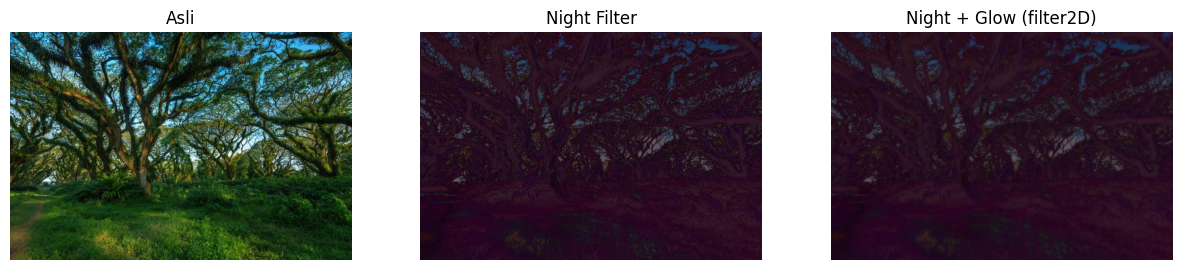

In [26]:
# Night Filter
# Load gambar baru untuk Percobaan 6 & 7
img = cv.imread("/content/drive/MyDrive/Pcvdk_Nawfal/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

# Tampilkan hasil
show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

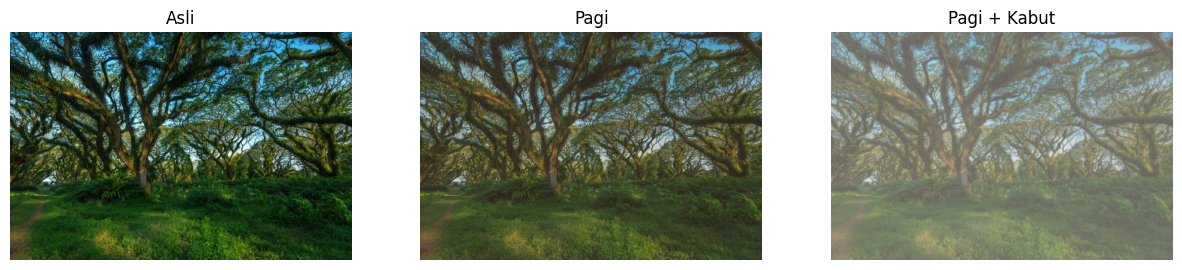

In [27]:
###Percobaan 7 (Suasana Pagi dan Kabut)**


# Filter Suasana pagi dan Kabut

# Step 1: Kurangi kontras & cerahkan

alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)


# Step 2: Tambahkan warm tone (kemerahan / oranye)

warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)


# Step 3: Tambahkan haze (kabut tipis) dengan filter2D

# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah Layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

# Tampilkan hasil
show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

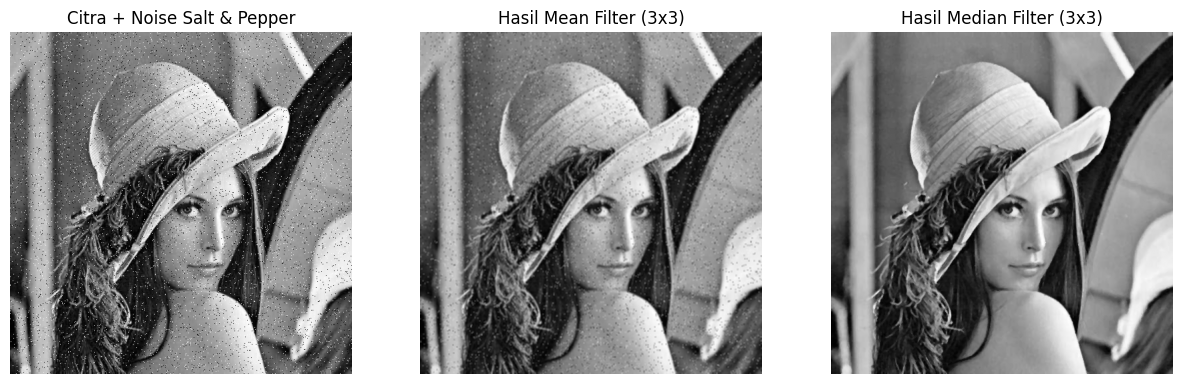

In [29]:
import numpy as np
import cv2 as cv
import random

# 1. TUGAS ANALISIS: MEAN VS MEDIAN FILTER


#Fungsi untuk menambahkan noise Salt and Pepper
def add_salt_and_pepper(image, prob=0.05):
    output = np.copy(image)
    # Probabilitas batas atas untuk salt (putih) dan pepper (hitam)
    threshold = 1 - prob
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            rdn = random.random()
            if rdn < prob:
                output[i][j] = 0       # Pepper (hitam)
            elif rdn > threshold:
                output[i][j] = 255     # Salt (putih)
    return output

# Gunakan img_gray dari percobaan sebelumnya
img_noisy = add_salt_and_pepper(img_gray, prob=0.02)

# Terapkan Mean Filter (3x3) dan Median Filter (3x3)
mean_filtered = cv.blur(img_noisy, (3, 3))
median_filtered = cv.medianBlur(img_noisy, 3)

# Tampilkan Hasil
show_side_by_side(
    [img_noisy, mean_filtered, median_filtered],
    ["Citra + Noise Salt & Pepper", "Hasil Mean Filter (3x3)", "Hasil Median Filter (3x3)"],
    figsize=(15, 5)
)

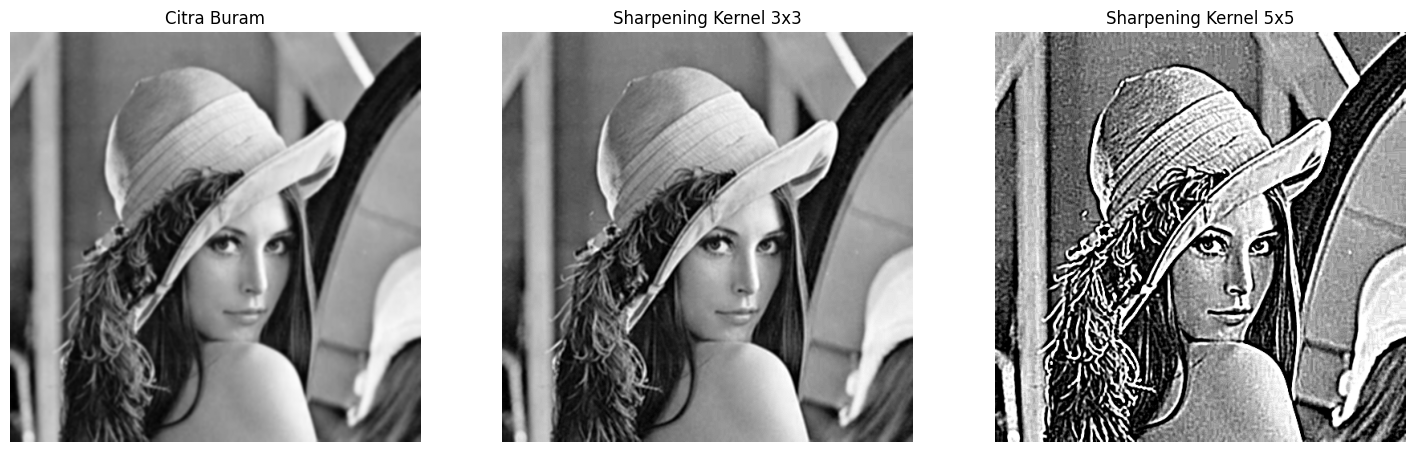

In [30]:
# 2. TUGAS EVALUASI: SHARPENING KERNEL

# Buat citra sedikit buram terlebih dahulu untuk diuji
img_blurry = cv.GaussianBlur(img_gray, (5, 5), 1.5)

# a. Buat kernel penajaman 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]])

# Kernel 5x5 (nilai tengah besar, dikelilingi nilai negatif)
kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, 25, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1]])

# b. Terapkan pada citra buram
sharpened_3x3 = cv.filter2D(img_blurry, -1, kernel_sharpen_3x3)
sharpened_5x5 = cv.filter2D(img_blurry, -1, kernel_sharpen_5x5)

# Tampilkan Hasil
show_side_by_side(
    [img_blurry, sharpened_3x3, sharpened_5x5],
    ["Citra Buram", "Sharpening Kernel 3x3", "Sharpening Kernel 5x5"],
    figsize=(18, 6)
)

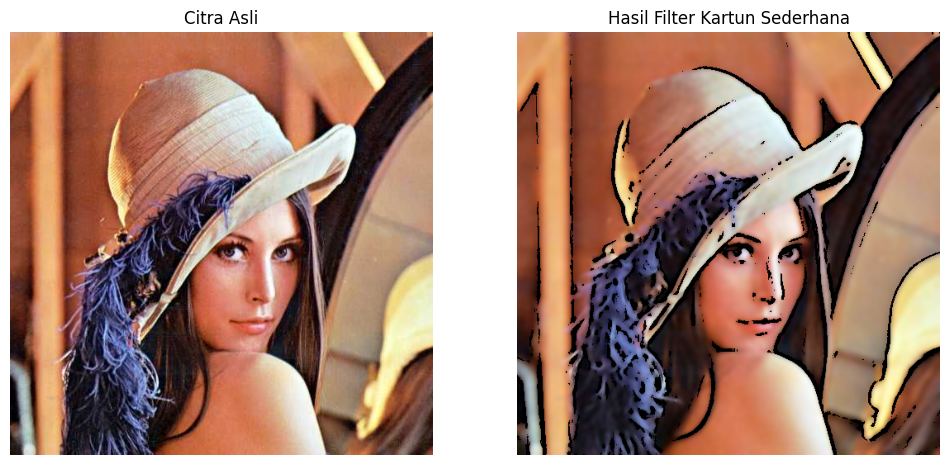

In [31]:
# 3. TUGAS KREASI: FILTER KARTUN SEDERHANA

# a. Buat fungsi kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna dengan Bilateral Filter agar area warna rata
    # d=9, sigmaColor=250, sigmaSpace=250 agar efek cat air/kartun lebih terasa
    color = cv.bilateralFilter(image, d=9, sigmaColor=250, sigmaSpace=250)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    # Median blur sedikit agar garis tepi tidak terlalu kotor oleh noise
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # 3. Penggabungan (kombinasi) dengan operasi logika (bitwise_and)
    # Konversi edges dari 1 channel (grayscale) kembali ke 3 channel (BGR)
    edges_colored = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # Gabungkan warna halus dengan garis tepi tebal
    hasil_kartun = cv.bitwise_and(color, edges_colored)

    return hasil_kartun

# b. Terapkan fungsi dan tampilkan bersebelahan
img_kartun = kartun(img)

show_side_by_side(
    [img, img_kartun],
    ["Citra Asli", "Hasil Filter Kartun Sederhana"],
    figsize=(12, 6)
)